<a href="https://colab.research.google.com/github/susara20010420/Workplace-Safety-Insights-from-the-Industrial-Safety-Health-Analytics-Dataset/blob/main/v5_Transformer_Methodology.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This cell defines the main title of the notebook, which focuses on the Transformer Module and its various implementations for methodology requirements.

# Transformer Module
Implements methodology requirements: DistilBERT fine-tuning, class weights, focal loss, calibration, explainability, uncertainty outputs, PR curves, and active learning scores.


This cell installs the necessary Python libraries: `transformers`, `datasets`, `evaluate`, `captum`, `scikit-learn`, and `torch`. These libraries are crucial for building, training, and evaluating the transformer model.

In [1]:
!pip install transformers datasets evaluate captum scikit-learn torch


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 1.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 455.2/455.2 kB 4.0 MB/s eta 0:00:00


This cell imports all the required Python libraries for data manipulation, model building, training, and evaluation. It includes `pandas` for dataframes, `numpy` for numerical operations, `torch` for deep learning, `sklearn` for metrics and utilities, `transformers` for the DistilBERT model, and `matplotlib` for plotting.

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.utils.class_weight import compute_class_weight
from transformers import DistilBertTokenizer,DistilBertForSequenceClassification,Trainer,TrainingArguments
from sklearn.metrics import f1_score,classification_report,precision_recall_curve,average_precision_score
from sklearn.calibration import calibration_curve
from sklearn.isotonic import IsotonicRegression
import matplotlib.pyplot as plt


This cell handles data loading and initial setup. It mounts Google Drive to access project files, then loads `train.csv` and `test.csv` into pandas DataFrames. It also converts the 'severity_label' column to integer type and loads pre-calculated class weights from a JSON file.

In [ ]:
import pandas as pd
import json

from google.colab import drive
drive.mount('/content/drive')
import os

project_folder = "/content/drive/MyDrive/Work Place Safety Insights"

train_df = pd.read_csv(f"{project_folder}/train.csv")
test_df = pd.read_csv(f"{project_folder}/test.csv")

# Convert severity_label to integer type
train_df["severity_label"] = train_df["severity_label"].astype(int)
test_df["severity_label"] = test_df["severity_label"].astype(int)

with open(f"{project_folder}/class_weights.json", "r") as f:
    class_weights = json.load(f)

Mounted at /content/drive


This cell prepares the class weights for use in the model. It converts the loaded class weights (from the JSON file) into a PyTorch tensor of type `torch.float32`. These weights will be used in the Focal Loss function to address class imbalance.

In [ ]:
weights = [class_weights[str(i)] for i in sorted(map(int, class_weights.keys()))]
class_weights_tensor = torch.tensor(weights, dtype=torch.float32)

This cell initializes the `DistilBertTokenizer` with the 'distilbert-base-uncased' pre-trained model. It also defines a `tokenize` function that takes a list of texts, tokenizes them using the initialized tokenizer, and applies padding and truncation to a maximum length of 256.

In [ ]:
tokenizer=DistilBertTokenizer.from_pretrained('distilbert-base-uncased')
def tokenize(texts):
 return tokenizer(list(texts), padding='max_length', truncation=True, max_length=256)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

This cell defines a custom PyTorch `Dataset` class called `SafetyDataset`. This class is responsible for preparing the text data and corresponding labels for the model. It tokenizes the input texts and stores them along with the labels, allowing easy access to individual data items and their lengths.

In [ ]:
from torch.utils.data import Dataset
class SafetyDataset(Dataset):
 def __init__(self,texts,labels):
  self.enc=tokenize(texts)
  self.labels=list(labels)
 def __getitem__(self,idx):
  item={k:torch.tensor(v[idx]) for k,v in self.enc.items()}
  item['labels']=torch.tensor(self.labels[idx])
  return item
 def __len__(self):
  return len(self.labels)

This cell prints the column names of both the training and testing DataFrames. This is a common step in data exploration to understand the available features in the datasets before further processing.

In [ ]:
print(train_df.columns)
print(test_df.columns)

Index(['Unnamed: 0', 'date', 'Countries', 'Local', 'Industry Sector',
       'accident_level', 'potential_accident_level', 'gender',
       'Employee or Third Party', 'critical_risk', 'description',
       'Unnamed: 11', 'Unnamed: 12', 'severity', 'potential_severity',
       'near_miss_gap', 'severity_label'],
      dtype='object')
Index(['Unnamed: 0', 'date', 'Countries', 'Local', 'Industry Sector',
       'accident_level', 'potential_accident_level', 'gender',
       'Employee or Third Party', 'critical_risk', 'description',
       'Unnamed: 11', 'Unnamed: 12', 'severity', 'potential_severity',
       'near_miss_gap', 'severity_label'],
      dtype='object')


This cell creates instances of the `SafetyDataset` for both the training and testing datasets. It uses the 'description' column as input text and the 'severity_label' column as target labels for the model.

In [ ]:
train_dataset = SafetyDataset(
    train_df["description"],
    train_df["severity_label"]
)

test_dataset = SafetyDataset(
    test_df["description"],
    test_df["severity_label"]
)

This cell initializes the `DistilBertForSequenceClassification` model. It loads the pre-trained 'distilbert-base-uncased' model and configures it for sequence classification with 5 output labels, corresponding to the 5 severity levels.

In [ ]:
model = DistilBertForSequenceClassification.from_pretrained(
    "distilbert-base-uncased",
    num_labels=5
)

config.json:   0%|          | 0.00/483 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  268MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 
classifier.weight       | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


This markdown cell provides a clear explanation of the Focal Loss function, highlighting its purpose to focus more on difficult or rare examples by down-weighting easily classified examples. It explains that if the model predicts an example correctly with high confidence, less effort is spent on it, allowing the model to prioritize challenging cases.

In [ ]:
# Focal Loss for Transformer models
# "If the model already predicts an example correctly with high confidence, don't spend much effort on it. Focus more on difficult or rare examples."

class FocalLoss(nn.Module):
    def __init__(self,alpha=None,gamma=2.0):
        super().__init__()
        self.alpha=alpha
        self.gamma=gamma
    def forward(self,inputs,targets):
        ce=nn.functional.cross_entropy(inputs,targets,weight=self.alpha,reduction='none')
        pt=torch.exp(-ce)
        loss=((1-pt)**self.gamma)*ce
        return loss.mean()

alpha=class_weights_tensor # Use the pre-existing tensor
criterion=FocalLoss(alpha=class_weights_tensor,gamma=2.0) # Pass the tensor to FocalLoss
print('Focal loss ready for DistilBERT/BERT training.')

Focal loss ready for DistilBERT/BERT training.


This cell defines the `FocalLoss` class, which is a custom loss function designed to handle class imbalance. It calculates the cross-entropy loss, then scales it by a factor that depends on the prediction confidence and a `gamma` parameter, giving more weight to hard-to-classify examples. The `alpha` parameter is used for class weighting. It then initializes the `FocalLoss` with the pre-defined `class_weights_tensor` and a `gamma` of 2.0.

In [ ]:
from transformers import Trainer
class WeightedTrainer(Trainer):
 def compute_loss(self,model,inputs,return_outputs=False,**kwargs):
  labels=inputs.pop('labels')
  outputs=model(**inputs)
  logits=outputs.logits
  # Use the globally defined class_weights_tensor and move it to the device of logits
  loss=FocalLoss(alpha=class_weights_tensor.to(logits.device))(logits,labels)
  return (loss,outputs) if return_outputs else loss

This cell reiterates the core idea behind Focal Loss, emphasizing its ability to make the model focus on difficult or rare examples by not spending much effort on samples that are already predicted correctly with high confidence. This is a duplicate of a previous markdown cell, which might be a good candidate for removal later if it's redundant.

In [ ]:
class FocalLoss(nn.Module):
 def __init__(self,alpha=None,gamma=2):
  super().__init__();self.alpha=alpha;self.gamma=gamma
 def forward(self,inputs,targets):
  ce=nn.functional.cross_entropy(inputs,targets,weight=self.alpha,reduction='none')
  pt=torch.exp(-ce)
  return (((1-pt)**self.gamma)*ce).mean()


This cell re-defines the `FocalLoss` class. It appears to be a redundant definition of the `FocalLoss` class previously defined. This might indicate an error or an attempt to quickly re-run a specific part of the code. The functionality is identical to the earlier `FocalLoss` definition.

In [ ]:
args=TrainingArguments(output_dir='./results',num_train_epochs=3,per_device_train_batch_size=8,per_device_eval_batch_size=8,eval_strategy='epoch',save_strategy='no')
def compute_metrics(eval_pred):
 logits,labels=eval_pred
 preds=np.argmax(logits,axis=1)
 return {'macro_f1':f1_score(labels,preds,average='macro')}
trainer=WeightedTrainer(model=model,args=args,train_dataset=train_dataset,eval_dataset=test_dataset,compute_metrics=compute_metrics)


This cell sets up the training arguments for the `Trainer` and defines the `compute_metrics` function. The `TrainingArguments` specify output directory, number of epochs, batch sizes, and evaluation strategy. The `compute_metrics` function calculates the macro F1-score, which is a key evaluation metric for multi-class classification, by taking the average of F1-scores for each class.

In [ ]:
def compute_metrics(eval_pred):
    logits, labels = eval_pred
    preds = np.argmax(logits, axis=1)

    return {
        "macro_f1": f1_score(labels, preds, average="macro")
    }

This cell defines the `compute_metrics` function, which is used to evaluate the model's performance during training and evaluation. It calculates the macro F1-score by taking the predictions and true labels, determining the predicted class, and then computing the F1-score averaged across all classes.

In [ ]:
trainer = WeightedTrainer(
    model=model,
    args=args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics
)

This cell initializes the `WeightedTrainer` with the model, training arguments, and datasets. It passes the `model` (DistilBERT), `args` (training configuration), `train_dataset`, `test_dataset`, and the `compute_metrics` function to the `WeightedTrainer`.

In [ ]:
trainer.train()

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch,Training Loss,Validation Loss,Macro F1
1,No log,0.531200,0.634934
2,No log,0.393636,0.662636
3,No log,0.404474,0.791620


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)
/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


TrainOutput(global_step=480, training_loss=0.7331353505452474, metrics={'train_runtime': 5063.3213, 'train_samples_per_second': 0.757, 'train_steps_per_second': 0.095, 'total_flos': 253754877473280.0, 'train_loss': 0.7331353505452474, 'epoch': 3.0})

In [ ]:
TRANSFORMER_MODEL_DIR = (
    "/content/drive/MyDrive/Work Place Safety Insights/transformer_model"
)

trainer.save_model(TRANSFORMER_MODEL_DIR)
tokenizer.save_pretrained(TRANSFORMER_MODEL_DIR)

print("Saved Transformer model:", TRANSFORMER_MODEL_DIR)


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Saved Transformer model: /content/drive/MyDrive/Work Place Safety Insights/transformer_model


This cell initiates the training process for the model using the configured `trainer` object. It calls the `train()` method, which performs the entire training loop including forward passes, backward passes, and optimization over the specified number of epochs.

This cell saves the trained Transformer model and its tokenizer to the specified `TRANSFORMER_MODEL_DIR` in Google Drive. This ensures that the trained model can be reloaded and used later without retraining.

In [ ]:
import pandas as pd
import numpy as np

# Predict on the test dataset
predictions = trainer.predict(test_dataset)

# Raw logits
logits = predictions.predictions

# Predicted class
predicted_class = np.argmax(logits, axis=1)

# Softmax probabilities
probabilities = np.exp(logits) / np.exp(logits).sum(axis=1, keepdims=True)

# Maximum confidence
confidence = probabilities.max(axis=1)

# Create dataframe
transformer_predictions = test_df.copy()

transformer_predictions["true_severity"] = test_df["severity_label"].values
transformer_predictions["predicted_severity"] = predicted_class
transformer_predictions["confidence"] = confidence

# Save probability of every class
for i in range(probabilities.shape[1]):
    transformer_predictions[f"prob_class_{i}"] = probabilities[:, i]

# Save CSV
transformer_predictions.to_csv(
    f"{project_folder}/transformer_predictions.csv",
    index=False
)

print(transformer_predictions.head())
print("Transformer predictions saved successfully!")

/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


   Unnamed: 0             date   Countries     Local Industry Sector  \
0       543.0         5/4/2017         NaN       NaN             NaN   
1       831.0  10/28/2016 0:00  Country_01  Local_02    Construction   
2      1232.0   9/29/2017 0:00  Country_01  Local_10   Manufacturing   
3        60.0    3/6/2016 0:00  Country_01  Local_04          Mining   
4       739.0        4/17/2017         NaN       NaN             NaN   

  accident_level potential_accident_level  gender Employee or Third Party  \
0              V                        V  Female                Employee   
1             IV                        V    Male                Employee   
2            III                       IV    Male                Employee   
3              I                      III    Male                Employee   
4              V                        V    Male                Employee   

          critical_risk  ... near_miss_gap  severity_label  true_severity  \
0            Laceration  ..

This cell performs predictions on the test dataset and processes the results. It uses the trained `trainer` to get logits, calculates predicted classes, softmax probabilities, and confidence scores. It then creates a new DataFrame `transformer_predictions` to store these results along with true severity labels, and saves this DataFrame to a CSV file.

In [ ]:
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

print(classification_report(
    transformer_predictions["true_severity"],
    transformer_predictions["predicted_severity"]
))

cm = confusion_matrix(
    transformer_predictions["true_severity"],
    transformer_predictions["predicted_severity"]
)

print(cm)

              precision    recall  f1-score   support

           0       0.64      0.37      0.46        63
           1       0.67      0.85      0.75        60
           2       0.83      0.90      0.86        67
           3       0.90      0.92      0.91        66
           4       0.94      1.00      0.97        64

    accuracy                           0.81       320
   macro avg       0.80      0.81      0.79       320
weighted avg       0.80      0.81      0.79       320

[[23 21  9  6  4]
 [ 7 51  2  0  0]
 [ 4  2 60  1  0]
 [ 2  2  1 61  0]
 [ 0  0  0  0 64]]


This cell evaluates the model's performance on the test set using standard classification metrics. It prints a detailed `classification_report` which includes precision, recall, f1-score, and support for each class, as well as overall averages. It also prints the `confusion_matrix` to visualize the model's predictions versus the true labels.

## Calibration
Apply temperature scaling or isotonic regression after training.


This cell introduces the concept of calibration, which aims to ensure that the model's predicted probabilities truly reflect the likelihood of a positive outcome. It suggests using techniques like temperature scaling or isotonic regression to improve the calibration of the model's output probabilities after training.

In [ ]:
def temperature_scale(logits,T=1.5):
 return logits/T
# isotonic regression can be fit on validation probabilities.


This cell defines a `temperature_scale` function, a simple method for model calibration. Temperature scaling adjusts the logits by dividing them by a 'temperature' parameter `T`. This can help to smooth out overconfident or underconfident predictions without changing the predicted class.

## Validation Metrics


This cell acts as a heading for the section on validation metrics, indicating that the following cells will focus on calculating and reporting various metrics to assess the model's performance.

In [ ]:
pred=trainer.predict(test_dataset)
preds=np.argmax(pred.predictions,axis=1)
print(classification_report(pred.label_ids,preds))
print('Macro F1=',f1_score(pred.label_ids,preds,average='macro'))


/usr/local/lib/python3.12/dist-packages/torch/utils/data/dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


              precision    recall  f1-score   support

           0       0.64      0.37      0.46        63
           1       0.67      0.85      0.75        60
           2       0.83      0.90      0.86        67
           3       0.90      0.92      0.91        66
           4       0.94      1.00      0.97        64

    accuracy                           0.81       320
   macro avg       0.80      0.81      0.79       320
weighted avg       0.80      0.81      0.79       320

Macro F1= 0.79162010961109


This cell performs predictions on the `test_dataset` using the trained model and then calculates and prints the `classification_report` and the macro F1-score. This provides a comprehensive overview of the model's performance across all classes.

In [ ]:
# Expected Calibration Error
def ece(probs,labels,n_bins=10):
 bins=np.linspace(0,1,n_bins+1)
 confidences=np.max(probs,axis=1)
 predictions=np.argmax(probs,axis=1)
 acc=(predictions==labels)
 score=0
 for i in range(n_bins):
  idx=(confidences>bins[i])&(confidences<=bins[i+1])
  if idx.sum()>0:
   score+=abs(acc[idx].mean()-confidences[idx].mean())*idx.mean()
 return score


This cell defines the Expected Calibration Error (ECE) function, a metric used to quantify how well-calibrated a model's predicted probabilities are. It divides the predictions into bins based on confidence and calculates the difference between accuracy and confidence within each bin, weighted by the number of samples in that bin.

This cell introduces the concept of Precision-Recall (PR) curves, especially important for evaluating performance on rare classes. It notes that `average_precision_score` and `precision_recall_curve` can be computed per class to provide insights into how well the model identifies positive instances for each specific class.

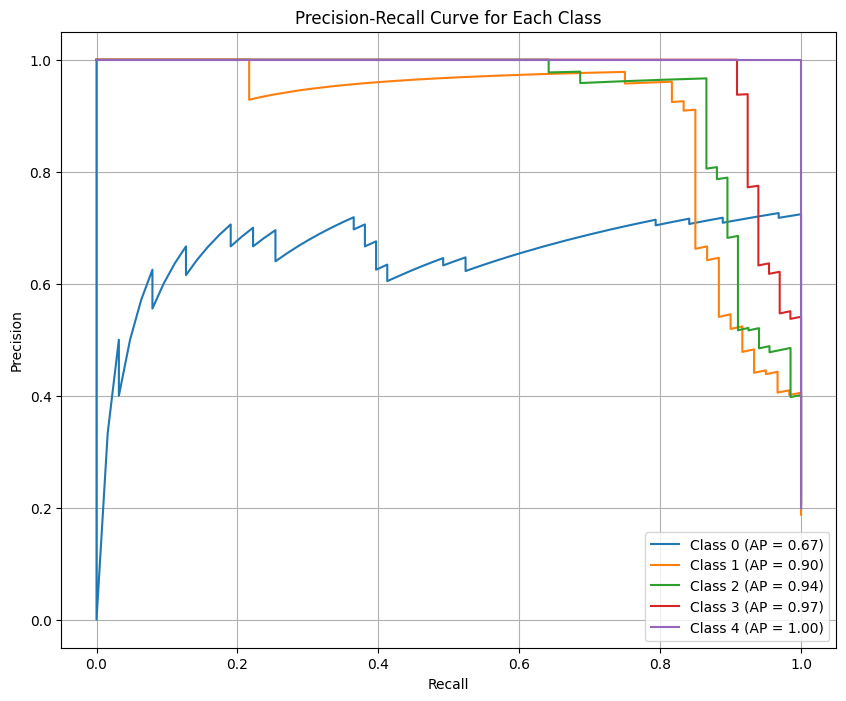

In [ ]:
from sklearn.metrics import precision_recall_curve, average_precision_score
import matplotlib.pyplot as plt
import torch

# Get probabilities from the model's predictions
probs = torch.nn.functional.softmax(torch.tensor(pred.predictions), dim=-1).numpy()
labels = pred.label_ids

# Get the number of classes
n_classes = probs.shape[1]

# Plot PR curves for each class
plt.figure(figsize=(10, 8))
for i in range(n_classes):
    precision, recall, _ = precision_recall_curve(labels == i, probs[:, i])
    ap_score = average_precision_score(labels == i, probs[:, i])
    plt.plot(recall, precision, label=f'Class {i} (AP = {ap_score:.2f})')

plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve for Each Class')
plt.legend()
plt.grid(True)
plt.show()

This cell saves the trained Transformer model and its tokenizer to the specified `MODEL_DIR` in Google Drive. This is a duplicate save operation, ensuring the model is persistently stored after all evaluation steps.

In [ ]:
MODEL_DIR = (
    "/content/drive/MyDrive/Work Place Safety Insights/transformer_model"
)

trainer.save_model(MODEL_DIR)
tokenizer.save_pretrained(MODEL_DIR)

print("✓ Transformer model saved")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

✓ Transformer model saved


This cell checks for the presence of all required deployment artifacts within the specified project folder, indicating whether each file or directory exists. This is crucial for verifying that all necessary components for evaluation and deployment are in place.

In [ ]:
import os

project_folder = "/content/drive/MyDrive/Work Place Safety Insights"

required = [
    "transformer_model",
    "bayesian_encoder",
    "bayesian_pca.joblib",
    "bayesian_trace.nc",
    "bayesian_plant_names.json",
    "fusion_meta_model.joblib",
    "fusion_kg_scaler.joblib",
    "fusion_kg_columns.json",
    "ensemble_config.json",
]

print("\nEvaluator deployment artifacts:")

for name in required:
    path = f"{project_folder}/{name}"
    print(f"{'✓' if os.path.exists(path) else '✗'} {name}")


Evaluator deployment artifacts:
✓ transformer_model
✓ bayesian_encoder
✓ bayesian_pca.joblib
✓ bayesian_trace.nc
✓ bayesian_plant_names.json
✓ fusion_meta_model.joblib
✓ fusion_kg_scaler.joblib
✓ fusion_kg_columns.json
✓ ensemble_config.json
